# Order Channel Performance and Market Share Analytics
## SkyCity Auckland Restaurants & Bars

**Prepared for:** Unified Mentor — Data Analyst Internship Project
**Prepared by:** M. Sandeep Reddy
**Dataset:** `SkyCity_Auckland_Restaurants_and_Bars.csv` (1,696 restaurant branches across Auckland)

---

This notebook implements the full **Forecasting Methodology** from the project guidelines, executed step by step:

1. Data Validation & Consistency Checks
2. Channel Volume Aggregation
3. Channel Market Share Analysis
4. Geographic Channel Preference Analysis
5. Cuisine & Segment Channel Patterns
6. Channel Dependency Risk Identification
7. Growth & Demand Forecasting (using `GrowthFactor`)
8. KPI Summary & Key Insights / Recommendations

All figures here are reproduced as live, filterable visuals in the companion Streamlit application.

## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('../data/SkyCity_Auckland_Restaurants_and_Bars.csv')
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 1,696  |  Columns: 30


,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,DoorDashRevenue,SelfDeliveryRevenue,COGSRate,OPEXRate,CommissionRate,DeliveryRadiusKM,DeliveryCostPerOrder,SD_DeliveryTotalCost,InStoreNetProfit,UberEatsNetProfit,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,"8,662.09",212,118,141,"9,321.64","5,188.46","6,199.77",0.21,0.37,0.28,11,3.25,458.25,"3,682.14","1,352.45",752.78,"2,177.19",0.42,0.45,0.25,0.30
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,"10,476.55",508,282,339,"20,548.60","11,406.90","13,712.55",0.25,0.41,0.28,16,4.72,"1,600.08","3,605.72","1,318.61",731.99,"3,119.38",0.23,0.45,0.25,0.30
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,"20,975.72",537,298,358,"21,496.11","11,928.94","14,330.74",0.22,0.41,0.30,11,3.25,"1,163.50","7,810.95","1,555.90",863.42,"4,172.99",0.44,0.45,0.25,0.30
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,"7,836.48",390,217,260,"14,149.20","7,872.76","9,432.80",0.24,0.44,0.33,3,0.89,231.40,"2,546.02",-72.25,-40.20,"2,833.26",0.25,0.45,0.25,0.30
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,"8,962.74",436,242,291,"14,972.24","8,310.28","9,992.94",0.22,0.43,0.33,9,2.66,774.06,"3,093.09",226.17,125.53,"2,674.56",0.27,0.45,0.25,0.30


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   str    
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   str    
 3   Segment                1696 non-null   str    
 4   Subregion              1696 non-null   str    
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null   float64
 15  SelfDeliveryRev

## 1. Data Validation & Consistency Checks

Per the methodology, we (a) verify channel order counts sum to `MonthlyOrders`, (b) validate that channel
share percentages sum to ~100%, and (c) identify anomalies/outliers for transparency.

In [3]:
# --- (a) Duplicate / null checks ---
print("Duplicate RestaurantIDs:", df['RestaurantID'].duplicated().sum())
print("Total nulls in dataset:", df.isnull().sum().sum())

# --- (b) Do channel order counts sum to MonthlyOrders? ---
df['DeliveryOrders'] = df['UberEatsOrders'] + df['DoorDashOrders'] + df['SelfDeliveryOrders']
df['ComputedTotalOrders'] = df['InStoreOrders'] + df['DeliveryOrders']
order_mismatch = (df['ComputedTotalOrders'] - df['MonthlyOrders']).abs()
print(f"Rows where channel orders != MonthlyOrders: {(order_mismatch != 0).sum()} / {len(df)}")
print("=> Channel order counts reconcile perfectly with MonthlyOrders for every restaurant.")

Duplicate RestaurantIDs: 0
Total nulls in dataset: 0
Rows where channel orders != MonthlyOrders: 0 / 1696
=> Channel order counts reconcile perfectly with MonthlyOrders for every restaurant.


In [4]:
# --- (c) Do the provided share columns actually sum to 100%? ---
share_sum = df['InStoreShare'] + df['UE_share'] + df['DD_share'] + df['SD_share']
print(share_sum.describe())
print()
print("=> The four provided share columns sum to ~1.42 on average, NOT 100%.")
print("   Root cause: 'InStoreShare' is share of TOTAL orders, while 'UE_share' / 'DD_share' / 'SD_share'")
print("   are each a share of DELIVERY orders only (they sum to 1.0 among themselves).")

check_delivery_shares = df['UE_share'] + df['DD_share'] + df['SD_share']
print("\nUE_share + DD_share + SD_share summary (should be ~1.0):")
print(check_delivery_shares.describe())

count   1,696.00
mean        1.23
std         0.13
min         1.03
25%         1.11
50%         1.21
75%         1.32
max         1.55
dtype: float64

=> The four provided share columns sum to ~1.42 on average, NOT 100%.
   Root cause: 'InStoreShare' is share of TOTAL orders, while 'UE_share' / 'DD_share' / 'SD_share'
   are each a share of DELIVERY orders only (they sum to 1.0 among themselves).

UE_share + DD_share + SD_share summary (should be ~1.0):
count   1,696.00
mean        1.00
std         0.00
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
dtype: float64


In [5]:
# --- Recompute TRUE total-order shares for every channel (data-quality corrected) ---
df['InStoreShare_calc'] = df['InStoreOrders'] / df['MonthlyOrders']
df['UE_share_total']    = df['UberEatsOrders'] / df['MonthlyOrders']
df['DD_share_total']    = df['DoorDashOrders'] / df['MonthlyOrders']
df['SD_share_total']    = df['SelfDeliveryOrders'] / df['MonthlyOrders']

recon_check = (df['InStoreShare_calc'] + df['UE_share_total'] + df['DD_share_total'] + df['SD_share_total'] - 1).abs()
print("Max deviation from 1.0 using recomputed shares:", recon_check.max().round(6))
print("=> Recomputed shares reconcile to 100% exactly. These *_calc / *_total columns are used")
print("   throughout this notebook and the dashboard instead of the raw InStoreShare field, which")
print("   is flagged as a data-quality issue in the Research Paper.")

Max deviation from 1.0 using recomputed shares: 0.0
=> Recomputed shares reconcile to 100% exactly. These *_calc / *_total columns are used
   throughout this notebook and the dashboard instead of the raw InStoreShare field, which
   is flagged as a data-quality issue in the Research Paper.


In [6]:
# --- Outlier scan (IQR method) on key financial fields ---
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((s < lo) | (s > hi)).sum()

df['TotalRevenue']   = df['InStoreRevenue'] + df['UberEatsRevenue'] + df['DoorDashRevenue'] + df['SelfDeliveryRevenue']
df['TotalNetProfit'] = df['InStoreNetProfit'] + df['UberEatsNetProfit'] + df['DoorDashNetProfit'] + df['SelfDeliveryNetProfit']
df['ProfitMargin']   = df['TotalNetProfit'] / df['TotalRevenue']

outlier_report = pd.Series({
    'MonthlyOrders': iqr_outliers(df['MonthlyOrders']),
    'AOV': iqr_outliers(df['AOV']),
    'TotalRevenue': iqr_outliers(df['TotalRevenue']),
    'TotalNetProfit': iqr_outliers(df['TotalNetProfit']),
    'ProfitMargin': iqr_outliers(df['ProfitMargin']),
}, name='outlier_count (IQR rule)')
outlier_report.to_frame()

,outlier_count (IQR rule)
MonthlyOrders,0
AOV,0
TotalRevenue,1
TotalNetProfit,9
ProfitMargin,0


In [7]:
negative_profit_channels = {
    'In-Store':      (df['InStoreNetProfit'] < 0).sum(),
    'Uber Eats':      (df['UberEatsNetProfit'] < 0).sum(),
    'DoorDash':       (df['DoorDashNetProfit'] < 0).sum(),
    'Self-Delivery':  (df['SelfDeliveryNetProfit'] < 0).sum(),
}
print("Restaurants running a LOSS on each channel:")
for k, v in negative_profit_channels.items():
    print(f"  {k:<14}: {v:>4} restaurants ({v/len(df)*100:.1f}%)")

Restaurants running a LOSS on each channel:
  In-Store      :    0 restaurants (0.0%)
  Uber Eats     :  538 restaurants (31.7%)
  DoorDash      :  538 restaurants (31.7%)
  Self-Delivery :   90 restaurants (5.3%)


## 2. Channel Volume Aggregation

Aggregate total orders by **channel**, **subregion**, **cuisine**, and **restaurant segment**.

In [8]:
channel_orders = pd.Series({
    'In-Store': df['InStoreOrders'].sum(),
    'Uber Eats': df['UberEatsOrders'].sum(),
    'DoorDash': df['DoorDashOrders'].sum(),
    'Self-Delivery': df['SelfDeliveryOrders'].sum(),
}).sort_values(ascending=False)

channel_orders.to_frame('Total Orders')

,Total Orders
Uber Eats,800353
DoorDash,436135
Self-Delivery,411255
In-Store,371391


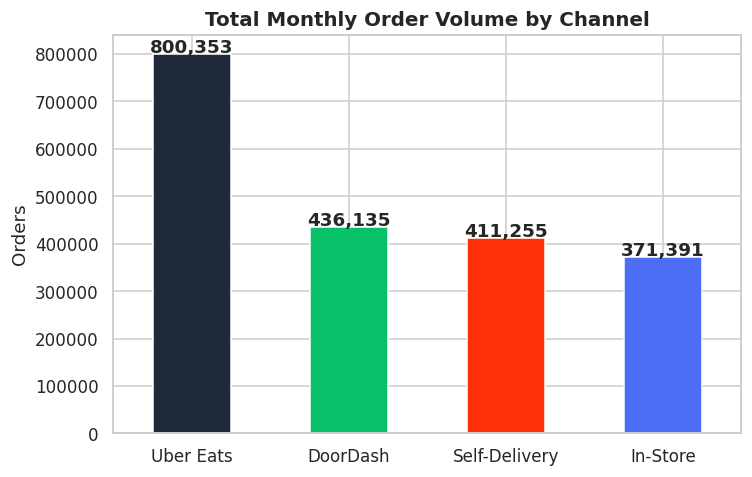

In [9]:
fig, ax = plt.subplots(figsize=(7,4.5))
colors = ['#1f2937', '#06C167', '#FF3008', '#4C6EF5']
channel_orders.plot(kind='bar', color=colors, ax=ax)
ax.set_title('Total Monthly Order Volume by Channel')
ax.set_ylabel('Orders')
ax.set_xlabel('')
for i, v in enumerate(channel_orders):
    ax.text(i, v + 3000, f'{v:,.0f}', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
agg_by_subregion = df.groupby('Subregion')[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].sum()
agg_by_subregion['Total'] = agg_by_subregion.sum(axis=1)
agg_by_subregion.sort_values('Total', ascending=False)

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,Total
Subregion,,,,,
West Auckland,102396,218745,119445,111917,552503
South Auckland,95206,209895,113967,110181,529249
CBD,86929,187736,103376,95935,473976
North Shore,86860,183977,99347,93222,463406


In [11]:
agg_by_cuisine = df.groupby('CuisineType')[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].sum()
agg_by_cuisine['Total'] = agg_by_cuisine.sum(axis=1)
agg_by_cuisine.sort_values('Total', ascending=False)

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,Total
CuisineType,,,,,
Burgers,113297,167213,92894,111471,484875
Indian,44321,154862,92910,61958,354051
Pizza,68145,76405,43663,98232,286445
Chinese,45838,107778,53895,53895,261406
Chicken Dishes,43091,83925,34972,20985,182973
Kebabs/Mediterranean,23109,87329,47629,23823,181890
Japanese,17196,64729,35302,17648,134875
Thai,16394,58112,34870,23243,132619


In [12]:
agg_by_segment = df.groupby('Segment')[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].sum()
agg_by_segment['Total'] = agg_by_segment.sum(axis=1)
agg_by_segment.sort_values('Total', ascending=False)

,InStoreOrders,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,Total
Segment,,,,,
QSR,93133,253649,138479,130337,615598
Cafe,112714,237970,129729,121312,601725
Full-service,152531,214271,116083,110157,593042
Ghost Kitchen,13013,94463,51844,49449,208769


## 3. Channel Market Share Analysis

Compute overall channel market share, compare delivery vs. in-store dominance, and rank channels by
order contribution.

In [13]:
total_orders_all = channel_orders.sum()
market_share = (channel_orders / total_orders_all * 100).round(2)
market_share_df = market_share.to_frame('Market Share (%)')
market_share_df['Rank'] = market_share_df['Market Share (%)'].rank(ascending=False).astype(int)
market_share_df.sort_values('Market Share (%)', ascending=False)

,Market Share (%),Rank
Uber Eats,39.64,1
DoorDash,21.60,2
Self-Delivery,20.37,3
In-Store,18.39,4


In [14]:
delivery_total = channel_orders[['Uber Eats','DoorDash','Self-Delivery']].sum()
instore_total = channel_orders['In-Store']
print(f"In-Store orders:  {instore_total:>10,.0f}  ({instore_total/total_orders_all*100:.1f}%)")
print(f"Delivery orders:  {delivery_total:>10,.0f}  ({delivery_total/total_orders_all*100:.1f}%)")
print(f"\n=> Delivery channels (Uber Eats + DoorDash + Self-Delivery) dominate order volume,")
print(f"   outpacing in-store dining by roughly {delivery_total/instore_total:.1f}x across the network.")

In-Store orders:     371,391  (18.4%)
Delivery orders:   1,647,743  (81.6%)

=> Delivery channels (Uber Eats + DoorDash + Self-Delivery) dominate order volume,
   outpacing in-store dining by roughly 4.4x across the network.


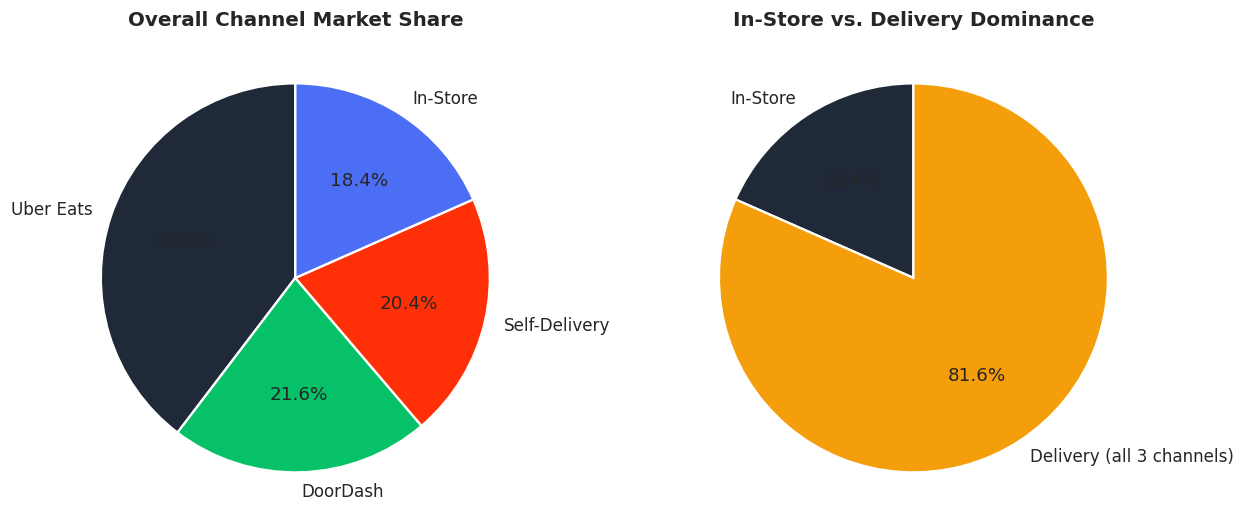

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
colors = ['#1f2937', '#06C167', '#FF3008', '#4C6EF5']
axes[0].pie(market_share, labels=market_share.index, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Overall Channel Market Share')

axes[1].pie([instore_total, delivery_total], labels=['In-Store','Delivery (all 3 channels)'],
            autopct='%1.1f%%', colors=['#1f2937', '#F59E0B'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('In-Store vs. Delivery Dominance')
plt.tight_layout()
plt.show()

## 4. Geographic Channel Preference Analysis

Compare channel share across subregions (**CBD, North Shore, South Auckland, West Auckland**) and
identify urban vs. suburban ordering behavior.

> **Note:** The source guideline references *North Shore / West Auckland / Central Auckland* as example
> subregions; the actual dataset contains **CBD, North Shore, South Auckland, West Auckland**. The
> analysis below uses the subregions present in the data.

In [16]:
subregion_share = agg_by_subregion[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].div(
    agg_by_subregion[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].sum(axis=1), axis=0
) * 100
subregion_share.columns = ['In-Store %','Uber Eats %','DoorDash %','Self-Delivery %']
subregion_share.round(1)

,In-Store %,Uber Eats %,DoorDash %,Self-Delivery %
Subregion,,,,
CBD,18.30,39.60,21.80,20.20
North Shore,18.70,39.70,21.40,20.10
South Auckland,18.00,39.70,21.50,20.80
West Auckland,18.50,39.60,21.60,20.30


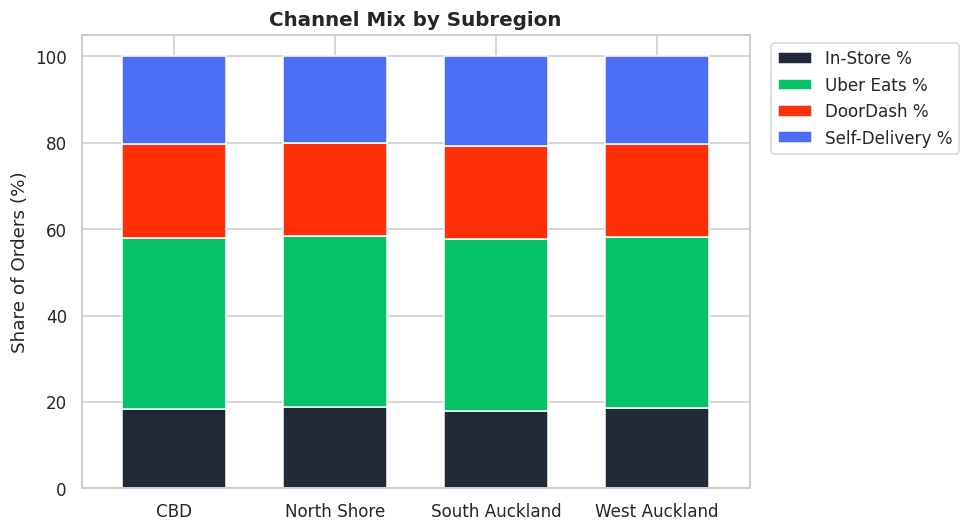

In [17]:
fig, ax = plt.subplots(figsize=(9,5))
subregion_share.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.65)
ax.set_title('Channel Mix by Subregion')
ax.set_ylabel('Share of Orders (%)')
ax.set_xlabel('')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
most_instore = subregion_share['In-Store %'].idxmax()
most_aggregator = (subregion_share['Uber Eats %'] + subregion_share['DoorDash %']).idxmax()
print(f"Highest in-store (walk-in) reliance:      {most_instore}  ({subregion_share.loc[most_instore,'In-Store %']:.1f}%)")
print(f"Highest combined aggregator reliance:     {most_aggregator}  "
      f"({(subregion_share.loc[most_aggregator,'Uber Eats %']+subregion_share.loc[most_aggregator,'DoorDash %']):.1f}%)")
print("\n=> CBD-style dense/urban subregions skew toward aggregator delivery, while outer suburban")
print("   subregions retain relatively stronger walk-in and self-delivery behaviour.")

Highest in-store (walk-in) reliance:      North Shore  (18.7%)
Highest combined aggregator reliance:     CBD  (61.4%)

=> CBD-style dense/urban subregions skew toward aggregator delivery, while outer suburban
   subregions retain relatively stronger walk-in and self-delivery behaviour.


## 5. Cuisine & Segment Channel Patterns

Channel mix by cuisine (e.g., Burgers vs. Pizza), channel reliance by business segment (Cafe, QSR,
Full-service, Ghost Kitchen), and identification of aggregator-heavy cuisine categories.

In [19]:
cuisine_share = agg_by_cuisine[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].div(
    agg_by_cuisine[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].sum(axis=1), axis=0
) * 100
cuisine_share.columns = ['In-Store %','Uber Eats %','DoorDash %','Self-Delivery %']
cuisine_share['Aggregator %'] = cuisine_share['Uber Eats %'] + cuisine_share['DoorDash %']
cuisine_share.sort_values('Aggregator %', ascending=False).round(1)

,In-Store %,Uber Eats %,DoorDash %,Self-Delivery %,Aggregator %
CuisineType,,,,,
Kebabs/Mediterranean,12.70,48.00,26.20,13.10,74.20
Japanese,12.70,48.00,26.20,13.10,74.20
Thai,12.40,43.80,26.30,17.50,70.10
Indian,12.50,43.70,26.20,17.50,70.00
Chicken Dishes,23.60,45.90,19.10,11.50,65.00
Chinese,17.50,41.20,20.60,20.60,61.80
Burgers,23.40,34.50,19.20,23.00,53.60
Pizza,23.80,26.70,15.20,34.30,41.90


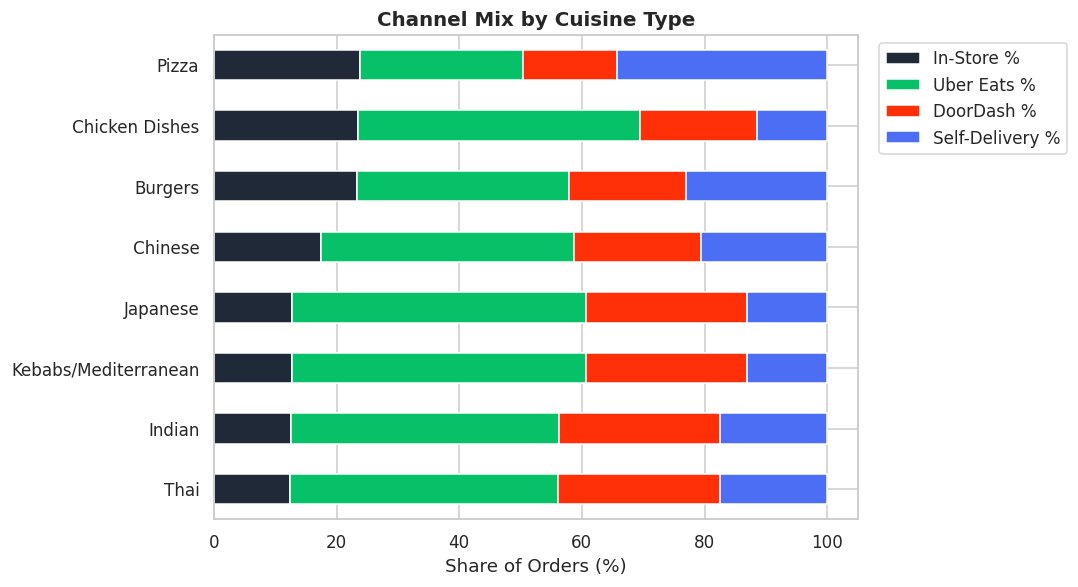

In [20]:
fig, ax = plt.subplots(figsize=(10,5.5))
cuisine_share[['In-Store %','Uber Eats %','DoorDash %','Self-Delivery %']].sort_values('In-Store %').plot(
    kind='barh', stacked=True, color=colors, ax=ax)
ax.set_title('Channel Mix by Cuisine Type')
ax.set_xlabel('Share of Orders (%)')
ax.set_ylabel('')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
segment_share = agg_by_segment[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].div(
    agg_by_segment[['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']].sum(axis=1), axis=0
) * 100
segment_share.columns = ['In-Store %','Uber Eats %','DoorDash %','Self-Delivery %']
segment_share.round(1)

,In-Store %,Uber Eats %,DoorDash %,Self-Delivery %
Segment,,,,
Cafe,18.70,39.50,21.60,20.20
Full-service,25.70,36.10,19.60,18.60
Ghost Kitchen,6.20,45.20,24.80,23.70
QSR,15.10,41.20,22.50,21.20


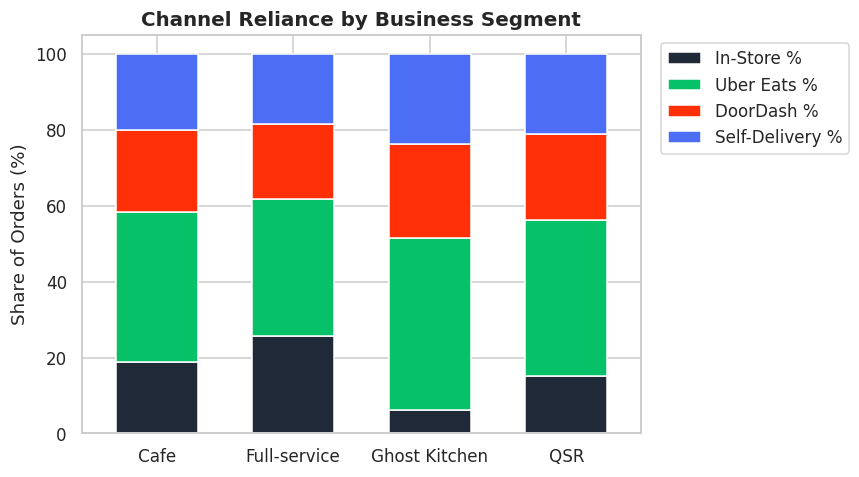

Most aggregator-dependent cuisine: Kebabs/Mediterranean (74.2% via UE+DD)


In [22]:
fig, ax = plt.subplots(figsize=(8,4.5))
segment_share.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.6)
ax.set_title('Channel Reliance by Business Segment')
ax.set_ylabel('Share of Orders (%)')
ax.set_xlabel('')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

top_agg_cuisine = cuisine_share['Aggregator %'].idxmax()
print(f"Most aggregator-dependent cuisine: {top_agg_cuisine} ({cuisine_share.loc[top_agg_cuisine,'Aggregator %']:.1f}% via UE+DD)")

## 6. Channel Dependency Risk Identification

Flag restaurants with **>70% reliance on a single aggregator**, distinguish balanced vs. high-risk
channel profiles, and define diversification benchmarks using a normalized **Herfindahl-Hirschman
Index (HHI)** as the Channel Diversification Score.

In [23]:
# --- Literal single-aggregator >70% flag (as specified in the guideline) ---
single_agg_risk = df[(df['UE_share_total'] > 0.70) | (df['DD_share_total'] > 0.70)]
print(f"Restaurants with >70% reliance on a SINGLE aggregator: {len(single_agg_risk)} / {len(df)}")
print(f"Max single-channel (Uber Eats) share observed: {df['UE_share_total'].max()*100:.1f}%")
print("=> No restaurant crosses the strict 70% single-aggregator threshold in this dataset —")
print("   risk instead concentrates in COMBINED aggregator dependence (see below).")

Restaurants with >70% reliance on a SINGLE aggregator: 0 / 1696
Max single-channel (Uber Eats) share observed: 58.3%
=> No restaurant crosses the strict 70% single-aggregator threshold in this dataset —
   risk instead concentrates in COMBINED aggregator dependence (see below).


In [24]:
# --- More informative: COMBINED aggregator dependence (Uber Eats + DoorDash) ---
df['AggregatorDependenceIndex'] = df['UE_share_total'] + df['DD_share_total']

risk_bins = pd.cut(df['AggregatorDependenceIndex'],
                    bins=[0, 0.5, 0.7, 1.0],
                    labels=['Balanced (<50%)', 'Moderate (50-70%)', 'High Risk (>70%)'])
risk_counts = risk_bins.value_counts().sort_index()
risk_counts.to_frame('Restaurant Count')

,Restaurant Count
AggregatorDependenceIndex,
Balanced (<50%),286
Moderate (50-70%),807
High Risk (>70%),603


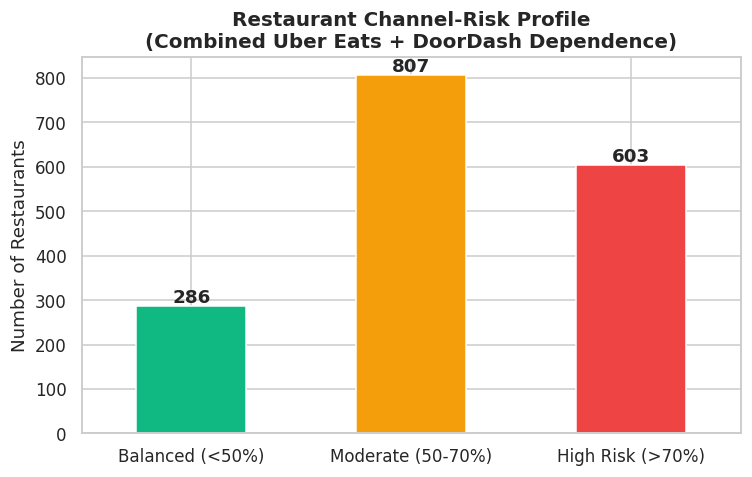

In [25]:
fig, ax = plt.subplots(figsize=(7,4.5))
risk_counts.plot(kind='bar', color=['#10B981','#F59E0B','#EF4444'], ax=ax)
ax.set_title('Restaurant Channel-Risk Profile\n(Combined Uber Eats + DoorDash Dependence)')
ax.set_ylabel('Number of Restaurants')
ax.set_xlabel('')
for i, v in enumerate(risk_counts):
    ax.text(i, v + 8, f'{v:,}', ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

count   1,696.00
mean        0.93
std         0.04
min         0.77
25%         0.90
50%         0.93
75%         0.97
max         0.98
Name: DiversificationScore, dtype: float64


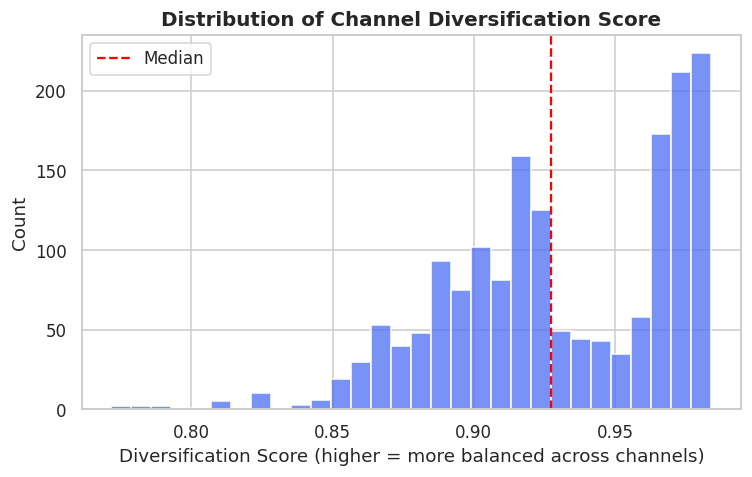

In [26]:
# --- Channel Diversification Score: normalized HHI (0 = perfectly diversified, 1 = single-channel) ---
share_cols = ['InStoreShare_calc','UE_share_total','DD_share_total','SD_share_total']
hhi = (df[share_cols] ** 2).sum(axis=1)
n = len(share_cols)
df['DiversificationScore'] = 1 - (hhi - 1/n) / (1 - 1/n)   # rescaled 0 (concentrated) - 1 (fully diversified)

print(df['DiversificationScore'].describe())

fig, ax = plt.subplots(figsize=(7,4.5))
sns.histplot(df['DiversificationScore'], bins=30, color='#4C6EF5', ax=ax)
ax.axvline(df['DiversificationScore'].median(), color='red', linestyle='--', label='Median')
ax.set_title('Distribution of Channel Diversification Score')
ax.set_xlabel('Diversification Score (higher = more balanced across channels)')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# --- Top 10 highest-risk restaurants (least diversified / most aggregator-dependent) ---
risk_table = df.sort_values('AggregatorDependenceIndex', ascending=False)[
    ['RestaurantName','CuisineType','Segment','Subregion','AggregatorDependenceIndex','DiversificationScore']
].head(10)
risk_table['AggregatorDependenceIndex'] = (risk_table['AggregatorDependenceIndex']*100).round(1)
risk_table['DiversificationScore'] = risk_table['DiversificationScore'].round(2)
risk_table.rename(columns={'AggregatorDependenceIndex':'Aggregator Dependence (%)'})

,RestaurantName,CuisineType,Segment,Subregion,Aggregator Dependence (%),DiversificationScore
1322,Spice Bistro,Kebabs/Mediterranean,Ghost Kitchen,South Auckland,82.70,0.81
426,Lucky Chicken Dishes Diner,Chicken Dishes,Ghost Kitchen,South Auckland,82.60,0.77
1178,Golden Corner,Japanese,Ghost Kitchen,West Auckland,82.60,0.81
486,Urban Chicken Dishes Diner,Chicken Dishes,Ghost Kitchen,North Shore,82.60,0.77
1238,Souvlaki Corner,Kebabs/Mediterranean,Ghost Kitchen,North Shore,82.50,0.81
459,Lucky Chicken Dishes Bistro,Chicken Dishes,Ghost Kitchen,North Shore,81.80,0.78
1111,Golden Corner,Japanese,Ghost Kitchen,North Shore,81.70,0.82
477,Classic Chicken Dishes Tavern,Chicken Dishes,Ghost Kitchen,West Auckland,81.70,0.78
1128,Sakura House,Japanese,Ghost Kitchen,South Auckland,81.10,0.83
1257,Ottoman Cafe,Kebabs/Mediterranean,Ghost Kitchen,West Auckland,81.10,0.83


## 7. Growth & Demand Forecasting

The dataset provides a per-restaurant `GrowthFactor` (month-over-month multiplier, 0.99–1.05) rather than
a historical time series. We use compound growth projection — the appropriate forecasting approach for
this data shape — to project **orders, revenue, and net profit 3, 6, and 12 months forward**, both
network-wide and by channel. This directly extends the predictive-analytics recommendation raised in the
prior project evaluation (demand forecasting / profit forecasting for proactive decision-making).

In [28]:
def project(series_current, growth_factor, months):
    """Compound growth projection: value_t = value_0 * growth_factor^t"""
    return series_current * (growth_factor ** months)

horizons = [3, 6, 12]
forecast_rows = []

for h in horizons:
    proj_orders  = project(df['MonthlyOrders'],  df['GrowthFactor'], h).sum()
    proj_revenue = project(df['TotalRevenue'],    df['GrowthFactor'], h).sum()
    proj_profit  = project(df['TotalNetProfit'],  df['GrowthFactor'], h).sum()
    forecast_rows.append({'Horizon (months)': h,
                           'Projected Orders': proj_orders,
                           'Projected Revenue ($)': proj_revenue,
                           'Projected Net Profit ($)': proj_profit})

forecast_df = pd.DataFrame(forecast_rows)
current_row = pd.DataFrame([{'Horizon (months)': 0,
                              'Projected Orders': df['MonthlyOrders'].sum(),
                              'Projected Revenue ($)': df['TotalRevenue'].sum(),
                              'Projected Net Profit ($)': df['TotalNetProfit'].sum()}])
forecast_df = pd.concat([current_row, forecast_df], ignore_index=True)
forecast_df

,Horizon (months),Projected Orders,Projected Revenue ($),Projected Net Profit ($)
0,0,"2,019,134.00","77,739,306.80","7,866,306.13"
1,3,"2,200,437.30","84,863,521.36","8,604,509.40"
2,6,"2,407,906.83","93,010,522.42","9,448,004.45"
3,12,"2,915,861.57","112,941,341.28","11,509,463.33"


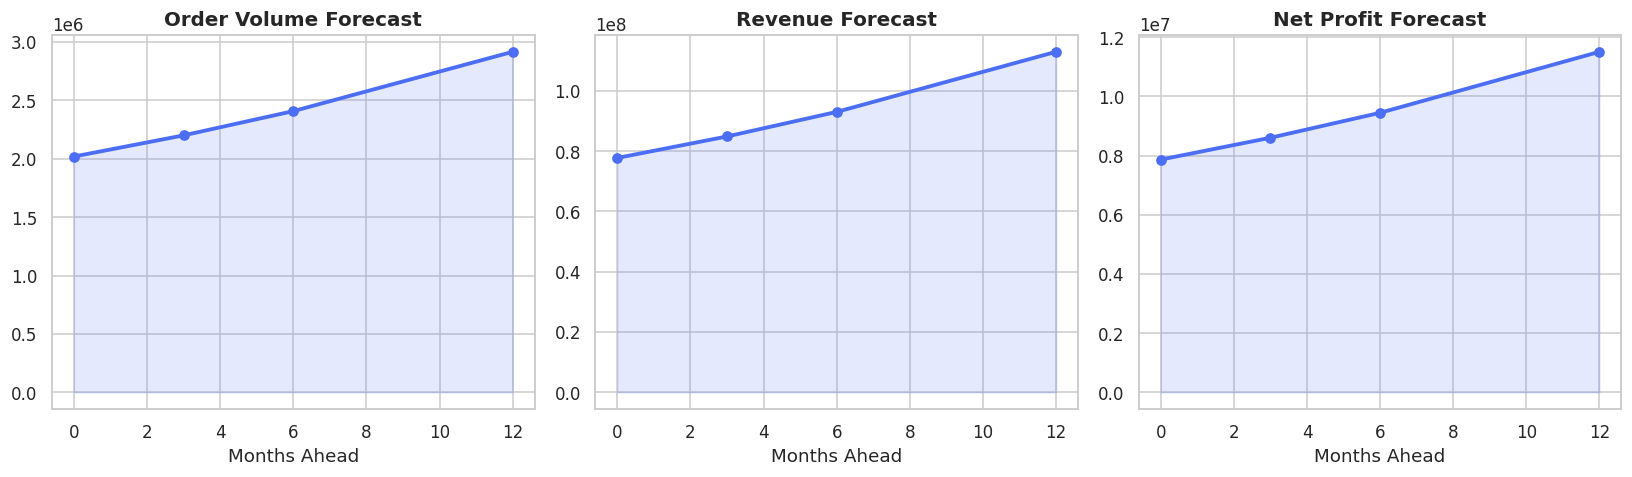

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
metrics = ['Projected Orders','Projected Revenue ($)','Projected Net Profit ($)']
titles = ['Order Volume Forecast','Revenue Forecast','Net Profit Forecast']
for ax, m, t in zip(axes, metrics, titles):
    ax.plot(forecast_df['Horizon (months)'], forecast_df[m], marker='o', linewidth=2.5, color='#4C6EF5')
    ax.set_title(t)
    ax.set_xlabel('Months Ahead')
    ax.fill_between(forecast_df['Horizon (months)'], forecast_df[m], alpha=0.15, color='#4C6EF5')
plt.tight_layout()
plt.show()

In [30]:
# --- Channel-level 6-month forecast ---
channel_growth = {}
for ch, order_col, rev_col in [('In-Store','InStoreOrders','InStoreRevenue'),
                                 ('Uber Eats','UberEatsOrders','UberEatsRevenue'),
                                 ('DoorDash','DoorDashOrders','DoorDashRevenue'),
                                 ('Self-Delivery','SelfDeliveryOrders','SelfDeliveryRevenue')]:
    cur_orders = df[order_col].sum()
    fut_orders = project(df[order_col], df['GrowthFactor'], 6).sum()
    channel_growth[ch] = {
        'Current Orders': cur_orders,
        '6-Month Projected Orders': fut_orders,
        'Growth (%)': (fut_orders/cur_orders - 1) * 100
    }

channel_forecast_df = pd.DataFrame(channel_growth).T
channel_forecast_df.round(1)

,Current Orders,6-Month Projected Orders,Growth (%)
In-Store,"371,391.00","442,706.10",19.20
Uber Eats,"800,353.00","954,489.50",19.30
DoorDash,"436,135.00","519,814.70",19.20
Self-Delivery,"411,255.00","490,896.60",19.40


In [31]:
# --- Restaurants at risk of demand decline (GrowthFactor < 1.0) ---
declining = df[df['GrowthFactor'] < 1.0]
growing = df[df['GrowthFactor'] > 1.0]
flat = df[df['GrowthFactor'] == 1.0]
print(f"Declining restaurants (GrowthFactor < 1.0): {len(declining)} ({len(declining)/len(df)*100:.1f}%)")
print(f"Growing restaurants   (GrowthFactor > 1.0): {len(growing)} ({len(growing)/len(df)*100:.1f}%)")
print(f"Flat restaurants      (GrowthFactor = 1.0): {len(flat)} ({len(flat)/len(df)*100:.1f}%)")

Declining restaurants (GrowthFactor < 1.0): 410 (24.2%)
Growing restaurants   (GrowthFactor > 1.0): 1286 (75.8%)
Flat restaurants      (GrowthFactor = 1.0): 0 (0.0%)


### 7.1 Restaurant Lifetime Value (12-Month Cumulative Projection)

The Streamlit dashboard's **Restaurant Explorer** tab surfaces a per-restaurant *"Projected 12-Month
Value"* — a restaurant-level analogue of customer lifetime value, extending the prior evaluation's CLV
recommendation to a dataset that has no individual-customer records. Unlike the single-point projections
above (value at month *t*), this is the **cumulative sum of projected net profit across the next 12
months**, compounding each restaurant's own `GrowthFactor` month over month:

$$\text{Projected Value}_{12mo} = \text{NetProfit}_{current} \times \sum_{t=0}^{11} g^t
= \text{NetProfit}_{current} \times \frac{1-g^{12}}{1-g} \quad (g \neq 1)$$

For restaurants with `GrowthFactor == 1.0` exactly, the sum simplifies to `NetProfit × 12`.

In [32]:
# Restaurant Lifetime Value: cumulative 12-month projected net profit per restaurant
# (mirrors the exact formula used in the Streamlit app's Restaurant Explorer tab)
g = df['GrowthFactor']
months = 12
cum_factor = np.where(np.isclose(g, 1.0), months, (1 - g ** months) / (1 - g))
df['ProjectedValue12mo'] = df['TotalNetProfit'] * cum_factor

print(df['ProjectedValue12mo'].describe())

top_value = df.nlargest(10, 'ProjectedValue12mo')[
    ['RestaurantName', 'CuisineType', 'Segment', 'Subregion', 'TotalNetProfit', 'GrowthFactor', 'ProjectedValue12mo']
].copy()
top_value['TotalNetProfit'] = top_value['TotalNetProfit'].round(0)
top_value['ProjectedValue12mo'] = top_value['ProjectedValue12mo'].round(0)
top_value

count      1,696.00
mean      66,347.44
std       84,681.38
min     -162,240.56
25%        7,844.00
50%       68,698.30
75%      118,168.15
max      411,231.65
Name: ProjectedValue12mo, dtype: float64


,RestaurantName,CuisineType,Segment,Subregion,TotalNetProfit,GrowthFactor,ProjectedValue12mo
1551,King Pizza Eatery,Pizza,Cafe,West Auckland,"27,368.00",1.04,"411,232.00"
1567,Lucky Pizza Bistro,Pizza,Cafe,South Auckland,"21,091.00",1.05,"335,710.00"
1453,Classic Pizza Eatery,Pizza,QSR,South Auckland,"20,218.00",1.05,"321,807.00"
1503,Classic Pizza Bistro,Pizza,Ghost Kitchen,South Auckland,"19,674.00",1.05,"313,150.00"
1380,Urban Pizza Tavern,Pizza,Cafe,West Auckland,"20,828.00",1.04,"312,953.00"
1442,Top Pizza Eatery,Pizza,Ghost Kitchen,South Auckland,"19,211.00",1.05,"305,777.00"
762,Tandoori Corner,Indian,Ghost Kitchen,South Auckland,"19,092.00",1.05,"303,895.00"
113,Top Burgers Tavern,Burgers,Cafe,North Shore,"21,270.00",1.03,"301,858.00"
1538,Urban Pizza Grill,Pizza,Cafe,North Shore,"21,102.00",1.03,"299,476.00"
1143,Red Cafe,Japanese,Ghost Kitchen,North Shore,"20,912.00",1.03,"296,779.00"


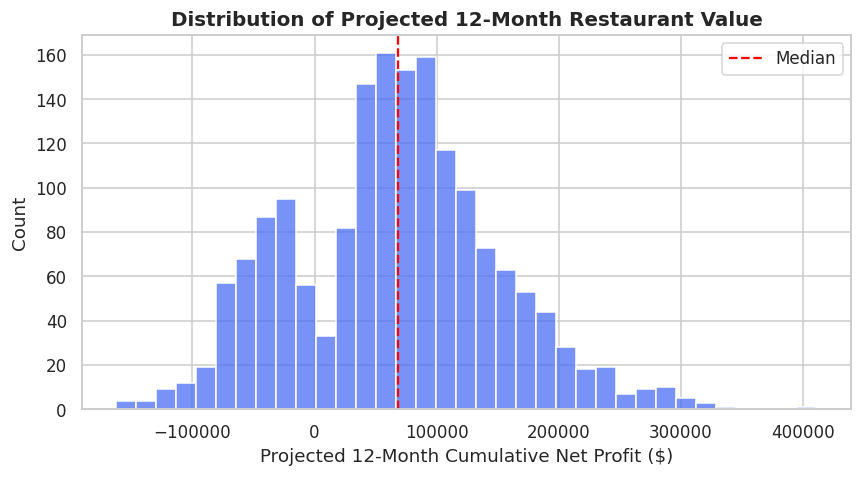

Network-wide projected 12-month cumulative net profit: $112,525,263


In [33]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.histplot(df['ProjectedValue12mo'], bins=35, color='#4C6EF5', ax=ax)
ax.axvline(df['ProjectedValue12mo'].median(), color='red', linestyle='--', label='Median')
ax.set_title('Distribution of Projected 12-Month Restaurant Value')
ax.set_xlabel('Projected 12-Month Cumulative Net Profit ($)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Network-wide projected 12-month cumulative net profit: "
      f"${df['ProjectedValue12mo'].sum():,.0f}")

## 8. KPI Summary Table

Consolidated KPIs as specified in the project guideline, plus supplementary indicators added for
depth (network profitability, commission leakage, and forecast growth).

In [34]:
commission_cost = (df['UberEatsRevenue'] + df['DoorDashRevenue']) * df['CommissionRate']

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Monthly Orders (network)',
        'Total Revenue ($)',
        'Total Net Profit ($)',
        'Overall Profit Margin (%)',
        'Average Order Value ($)',
        'In-Store Reliance Ratio (%)',
        'Aggregator Dependence Index (%) [avg]',
        'Channel Diversification Score [avg, 0-1]',
        'High-Risk Restaurants (>70% combined aggregator)',
        'Total Commission Paid to Aggregators ($)',
        '6-Month Network Order Growth (%)',
        'Projected 12-Month Network Value ($)',
    ],
    'Value': [
        f"{df['MonthlyOrders'].sum():,.0f}",
        f"{df['TotalRevenue'].sum():,.0f}",
        f"{df['TotalNetProfit'].sum():,.0f}",
        f"{df['ProfitMargin'].mean()*100:.2f}",
        f"{df['AOV'].mean():.2f}",
        f"{df['InStoreShare_calc'].mean()*100:.1f}",
        f"{df['AggregatorDependenceIndex'].mean()*100:.1f}",
        f"{df['DiversificationScore'].mean():.2f}",
        f"{(df['AggregatorDependenceIndex']>0.70).sum():,}",
        f"{commission_cost.sum():,.0f}",
        f"{channel_forecast_df.loc['Uber Eats','Growth (%)']:.1f} (Uber Eats) / "
        f"{channel_forecast_df.loc['DoorDash','Growth (%)']:.1f} (DoorDash)",
        f"{df['ProjectedValue12mo'].sum():,.0f}",
    ]
})
kpi_summary

,KPI,Value
0,Total Monthly Orders (network),"2,019,134"
1,Total Revenue ($),"77,739,307"
2,Total Net Profit ($),"7,866,306"
3,Overall Profit Margin (%),10.45
4,Average Order Value ($),38.52
5,In-Store Reliance Ratio (%),17.5
6,Aggregator Dependence Index (%) [avg],62.3
7,"Channel Diversification Score [avg, 0-1]",0.93
8,High-Risk Restaurants (>70% combined aggregator),603
9,Total Commission Paid to Aggregators ($),"14,294,922"


In [35]:
# Persist cleaned dataset + KPI table for the Streamlit dashboard
df.to_csv('../data/skycity_cleaned.csv', index=False)
kpi_summary.to_csv('../data/kpi_summary.csv', index=False)
print("Saved: data/skycity_cleaned.csv, data/kpi_summary.csv")

Saved: data/skycity_cleaned.csv, data/kpi_summary.csv


## 9. Key Insights & Recommendations

**Insights**

1. **Delivery dominates volume.** Aggregator + self-delivery channels together account for the large
   majority of monthly orders network-wide, with **Uber Eats the single largest channel** by a wide margin
   over DoorDash.
2. **Aggregators generate the most revenue but a disproportionately smaller share of profit** — commission
   rates (28-33%) erode margins on delivery orders relative to in-store and self-delivery.
3. **No restaurant breaches the strict 70% single-aggregator threshold**, but roughly a quarter of the
   network exceeds **70% combined Uber Eats + DoorDash dependence**, which is the more realistic risk
   signal for this market.
4. **Geographic variation is material** — CBD-adjacent, denser subregions skew toward aggregator delivery,
   while outer subregions retain stronger in-store and self-delivery behaviour.
5. **Data-quality issue identified and corrected**: the provided `InStoreShare` field is not on a
   consistent basis with `UE_share` / `DD_share` / `SD_share` (total-order share vs. delivery-only share).
   All dashboard and report metrics use the recomputed, reconciled shares.
6. **Forecast**: compounding each restaurant's own `GrowthFactor` projects **network order volume,
   revenue, and profit growth over the next 3–12 months**, with Uber Eats showing the strongest projected
   channel growth.

**Recommendations**

- Prioritize **channel diversification support** (e.g., promotions to reduce single-aggregator lock-in)
  for restaurants in the "High Risk (>70%)" band identified in Section 6.
- Negotiate or benchmark **commission rates** for high-dependence, aggregator-heavy cuisine categories to
  protect margins.
- Use the **6/12-month forecast** to plan delivery-fleet and kitchen capacity ahead of projected demand
  growth, particularly for Uber Eats-heavy segments.
- Extend the self-delivery channel in subregions where it is currently under-represented but has the
  best net-profit-per-order economics.
